In [10]:
from pathlib import Path
import pandas as pd

file_path_m = Path.home() / "Downloads" / "mechanisms.xlsx"
mechanisms = pd.read_excel(file_path_m)

file_path_t = Path.home() / "Downloads" / "triggers.xlsx"
triggers = pd.read_excel(file_path_t)


mechanisms.head()

,Table 1.6.2-2Mechanisms of injury for US and Canadian scuba fatalities,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Mechanism,2016,2015,2014,2010,2011,2012,2013,2017,2018
1,Breathing Issues/ Out of air,2,0,3,7,9,7,10,2,1
2,Panic,3,1,0,0,2,5,0,0,0
3,Ascent/ Pressure-related,3,5,2,19,8,4,2,4,4
4,Exhaustion,2,0,0,0,0,1,1,0,0


In [11]:
file_path_r = Path.home() / "Downloads" / "region_country.xlsx"
region_country = pd.read_excel(file_path_r)

file_path_max = Path.home() / "Downloads" / "max_depth.xlsx"
max_depth = pd.read_excel(file_path_max)

file_path_certifications = Path.home() / "Downloads" / "certifications.xlsx"
certifications = pd.read_excel(file_path_certifications)

In [7]:
print("region_country shape:", region_country.shape)
print("columns:", list(region_country.columns))
display(region_country.head(10))

region_country shape: (100, 12)
columns: ['Region', 'country', 'number 2016', 2010, 2011, 2012, 2013, 2014, 2015, 2017, 2019, 2020]


,Region,country,number 2016,2010,2011,2012,2013,2014,2015,2017,2019,2020
0,North America,NaN,72.0,62,90,73,67,60,46,85,77,58
1,NaN,United States,59.0,56,74,56,48,50,39,71,67,49
2,NaN,Mexico,8.0,1,9,9,8,6,2,6,5,3
3,NaN,Canada,5.0,4,6,7,10,4,4,8,5,6
4,NaN,Bermuda,0.0,0,1,1,1,0,1,0,0,0
5,NaN,Greenland,0.0,1,0,0,0,0,0,0,0,0
6,Oceania,NaN,23.0,12,18,11,19,14,18,24,25,18
7,NaN,Australia,14.0,6,11,7,11,5,8,7,14,9
8,NaN,French Polynesia,0.0,0,0,0,0,0,1,3,0,1
9,NaN,Marshall Island,0.0,0,0,0,0,0,1,0,0,0


,Region,year,fatalities,total_fatalities,proportion
0,North America,2010,62.0,117.0,0.529915
1,Oceania,2010,12.0,117.0,0.102564
2,Caribbean,2010,6.0,117.0,0.051282
3,South America,2010,1.0,117.0,0.008547
4,Northern Africa,2010,4.0,117.0,0.034188


,Region,country,year,fatalities,total_fatalities,proportion
0,North America,United States,2010,56.0,117.0,0.478632
1,North America,Mexico,2010,1.0,117.0,0.008547
2,North America,Canada,2010,4.0,117.0,0.034188
3,North America,Bermuda,2010,0.0,117.0,0.000000
4,North America,Greenland,2010,1.0,117.0,0.008547


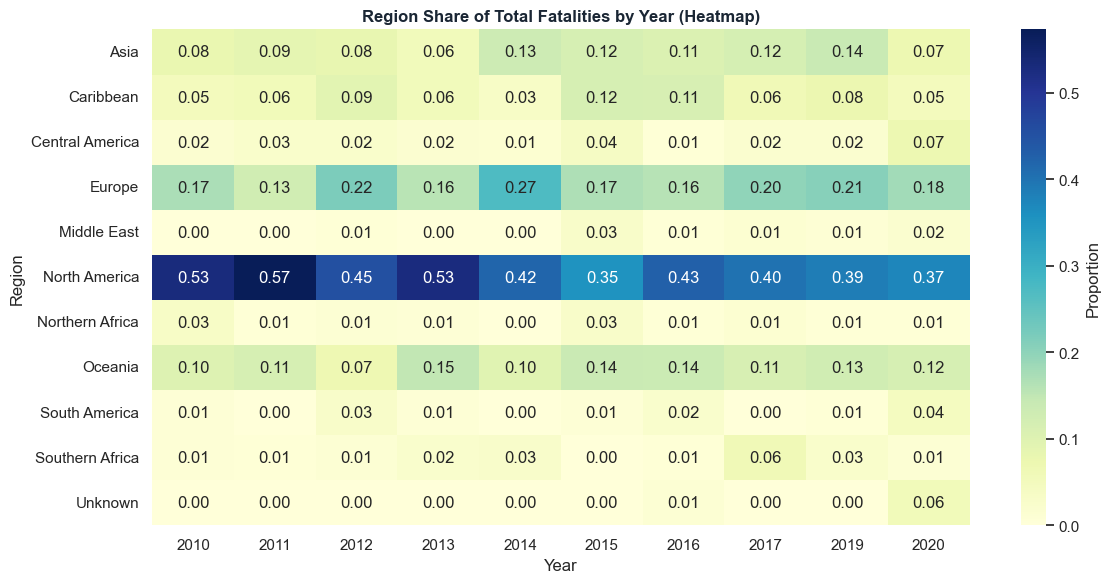

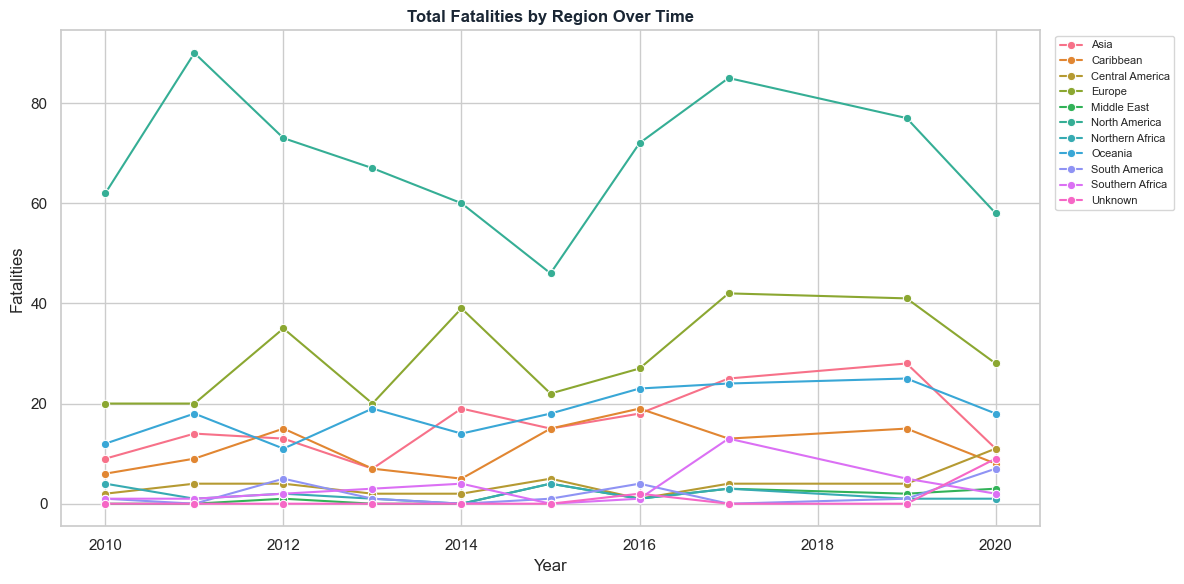

Top 10 countries by total fatalities:


,country,fatalities
78,United States,569.0
2,Australia,92.0
77,United Kingdom,69.0
11,Canada,59.0
44,Mexico,57.0
50,New Zealand,52.0
36,Italy,37.0
54,Philippines,31.0
52,Other,31.0
34,Indonesia,31.0


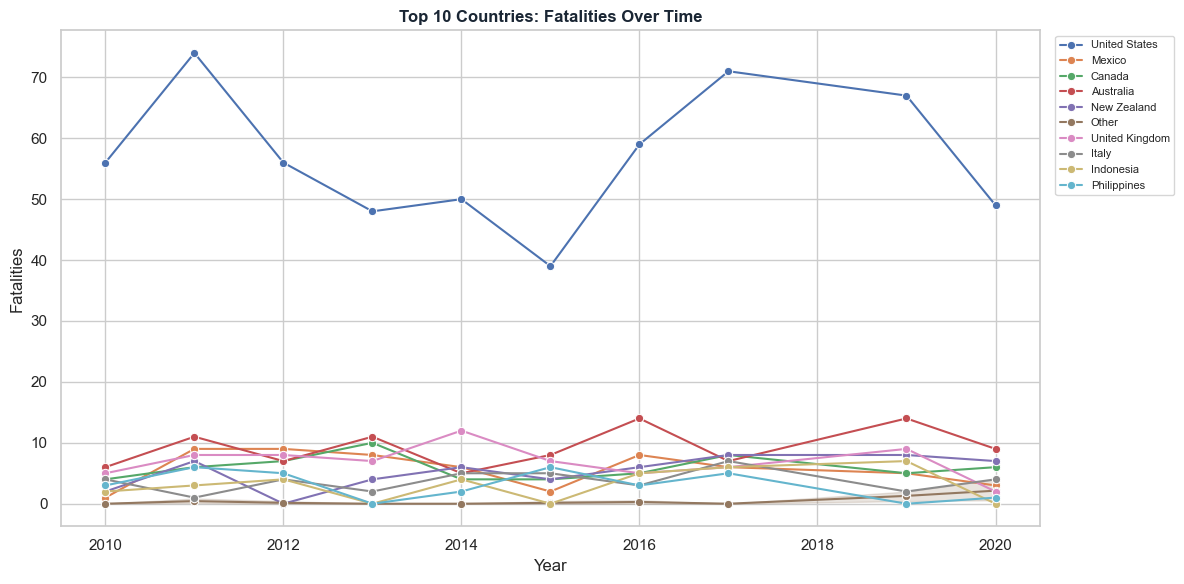

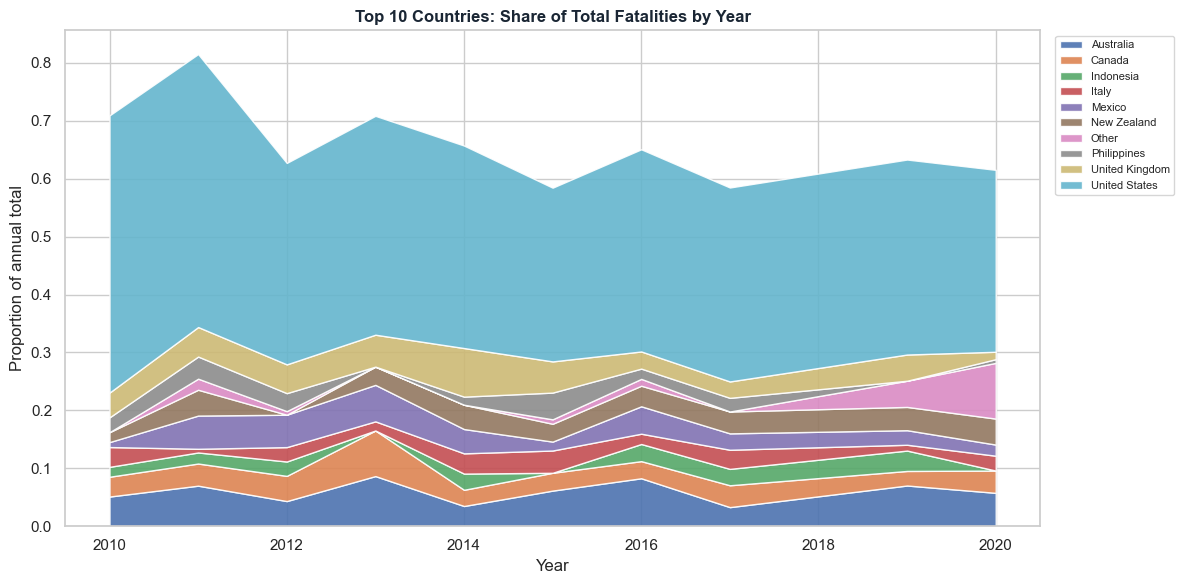

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

###reshaping
rc = region_country.copy()
rc.columns = [str(c).strip() for c in rc.columns]


year_map = {}
for col in rc.columns:
    m = re.search(r"(19\d{2}|20\d{2})", str(col))
    if m:
        year_map[col] = int(m.group(1))

if not year_map:
    raise ValueError("No year columns found in region_country")

rc = rc.rename(columns=year_map)
year_cols = sorted([c for c in rc.columns if isinstance(c, int)])

#fwrd fill region name to country rows
rc["Region"] = rc["Region"].ffill()

##region total rows are those with no country value
region_rows = rc[rc["country"].isna()].copy()
country_rows = rc[rc["country"].notna()].copy()


region_long = region_rows.melt(id_vars=["Region"], value_vars=year_cols, var_name="year", value_name="fatalities")
region_long["fatalities"] = pd.to_numeric(region_long["fatalities"], errors="coerce").fillna(0)
region_long["year"] = region_long["year"].astype(int)

country_long = country_rows.melt(id_vars=["Region", "country"], value_vars=year_cols, var_name="year", value_name="fatalities")
country_long["fatalities"] = pd.to_numeric(country_long["fatalities"], errors="coerce").fillna(0)
country_long["year"] = country_long["year"].astype(int)

#totals by year from region totals
year_totals = region_long.groupby("year", as_index=False)["fatalities"].sum().rename(columns={"fatalities": "total_fatalities"})

###proportions of total by year
region_prop = region_long.merge(year_totals, on="year", how="left")
region_prop["proportion"] = np.where(region_prop["total_fatalities"] > 0, region_prop["fatalities"] / region_prop["total_fatalities"], 0)

country_prop = country_long.merge(year_totals, on="year", how="left")
country_prop["proportion"] = np.where(country_prop["total_fatalities"] > 0, country_prop["fatalities"] / country_prop["total_fatalities"], 0)


display(region_prop.head())
display(country_prop.head())

# CHART 1: Region share of total fatalities by year (heatmap)
region_share_heatmap = (
    region_prop.pivot_table(index="Region", columns="year", values="proportion", aggfunc="sum", fill_value=0)
    .sort_index()
)
plt.figure(figsize=(12, 6))
sns.heatmap(region_share_heatmap, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={"label": "Proportion"})
plt.title("Region Share of Total Fatalities by Year (Heatmap)")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# CHART 2: Totals of fatalities by region over time (separate chart)
region_totals_ts = region_long.groupby(["year", "Region"], as_index=False)["fatalities"].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(data=region_totals_ts, x="year", y="fatalities", hue="Region", marker="o")
plt.title("Total Fatalities by Region Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

#top 10 countries by total fatalities
top10_countries = (
    country_long.groupby("country", as_index=False)["fatalities"]
    .sum()
    .sort_values("fatalities", ascending=False)
    .head(10)
)
print("Top 10 countries by total fatalities:")
display(top10_countries)

top10_list = top10_countries["country"].tolist()
top10_country_ts = country_long[country_long["country"].isin(top10_list)].copy()

# ---------- Chart 3: Top 10 countries fatalities over time ----------
plt.figure(figsize=(12, 6))
sns.lineplot(data=top10_country_ts, x="year", y="fatalities", hue="country", marker="o")
plt.title("Top 10 Countries: Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

# proportions for top 10 countries
top10_country_prop = country_prop[country_prop["country"].isin(top10_list)].copy()
top10_prop_pivot = top10_country_prop.pivot_table(index="year", columns="country", values="proportion", aggfunc="sum", fill_value=0).sort_index()
plt.figure(figsize=(12, 6))
plt.stackplot(top10_prop_pivot.index, top10_prop_pivot.values.T, labels=top10_prop_pivot.columns, alpha=0.9)
plt.title("Top 10 Countries: Share of Total Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Proportion of annual total")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

Most common max depth categories (overall):


,category,count
4,up to 30 ft,79
0,31-60,75
1,61-90,52
3,more than 120,49
2,91-120,40


/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_4841/688760438.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_depth_overall, x="count", y="category", palette="viridis")


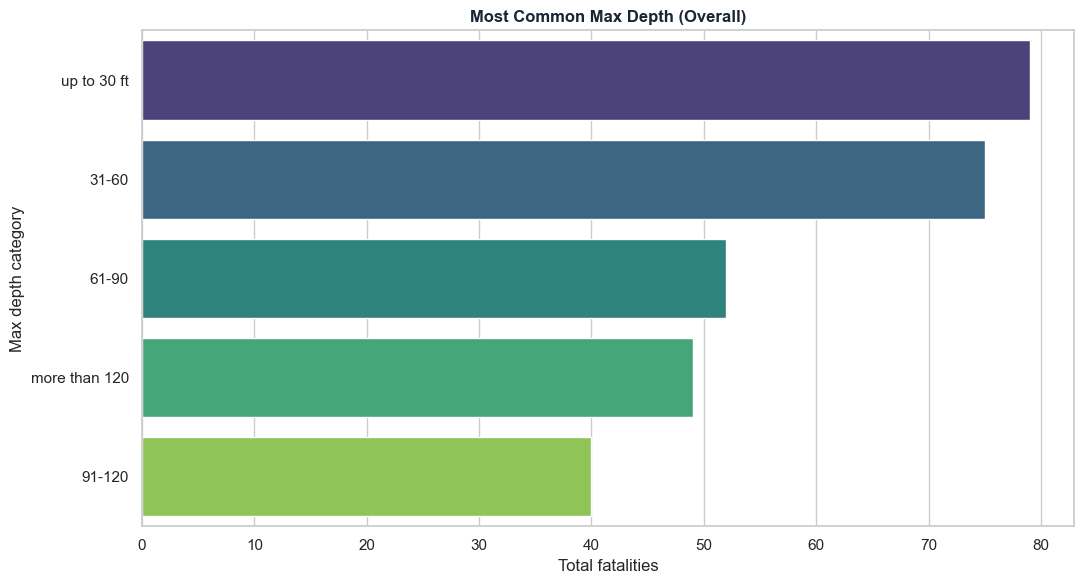

/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_4841/688760438.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_depth_ts = max_depth_top.groupby(["period", "category"], as_index=False)["count"].sum()


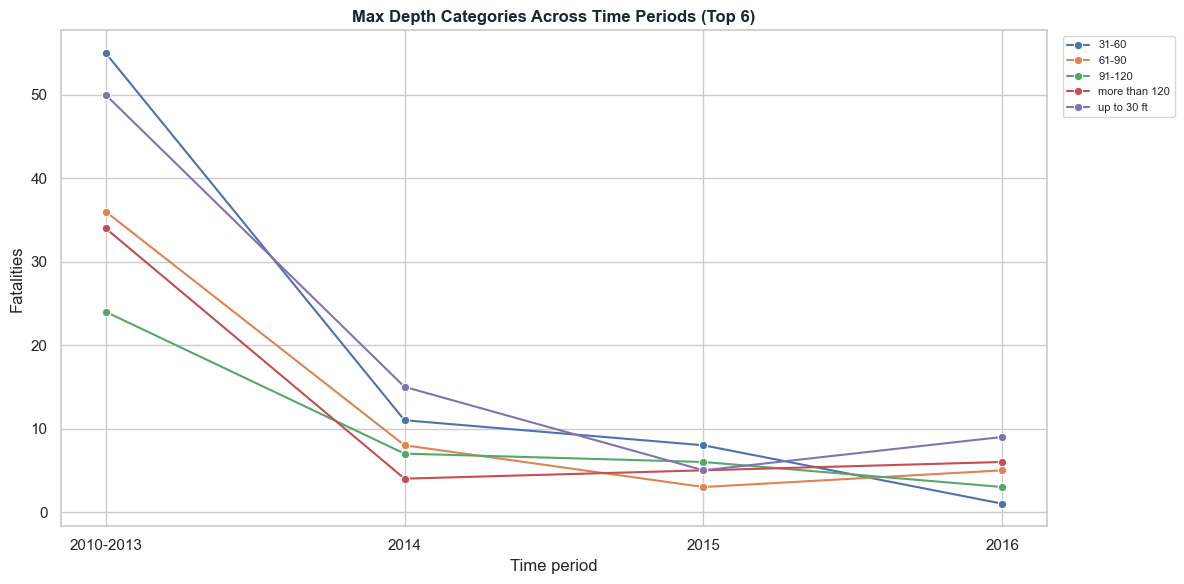

In [13]:
#Max depth
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

md = max_depth.copy()
md.columns = [str(c).strip() for c in md.columns]

# Identify columns
category_col = next((c for c in md.columns if "max depth" in c.lower()), md.columns[1])
time_cols = [c for c in md.columns if re.search(r"^\d{4}(?:-\d{4})?$", str(c).strip())]

if not time_cols:
    raise ValueError(f"No year/time-period columns found in max_depth. Columns: {list(md.columns)}")

#long table
max_depth_long = md.melt(id_vars=[category_col], value_vars=time_cols, var_name="period", value_name="count")
max_depth_long = max_depth_long.rename(columns={category_col: "category"})
max_depth_long["category"] = max_depth_long["category"].astype(str).str.strip()
max_depth_long["count"] = pd.to_numeric(max_depth_long["count"], errors="coerce")
max_depth_long = max_depth_long.dropna(subset=["count", "category"])


max_depth_long = max_depth_long[~max_depth_long["category"].str.lower().isin(["max depth", "total", "nan"])]
max_depth_long = max_depth_long[~max_depth_long["category"].str.lower().str.startswith("table")]

#Order periods (by starting year)
period_order = sorted(max_depth_long["period"].unique(), key=lambda x: int(str(x).split("-")[0]))
max_depth_long["period"] = pd.Categorical(max_depth_long["period"], categories=period_order, ordered=True)

#Most common max depth overall
max_depth_overall = (
    max_depth_long.groupby("category", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)
print("Most common max depth categories (overall):")
display(max_depth_overall)

plt.figure(figsize=(11, 6))
sns.barplot(data=max_depth_overall, x="count", y="category", palette="viridis")
plt.title("Most Common Max Depth (Overall)")
plt.xlabel("Total fatalities")
plt.ylabel("Max depth category")
plt.tight_layout()
plt.show()

#Across periods: top 6 categories over time
top_depth_categories = max_depth_overall.head(6)["category"].tolist()
max_depth_top = max_depth_long[max_depth_long["category"].isin(top_depth_categories)].copy()
max_depth_ts = max_depth_top.groupby(["period", "category"], as_index=False)["count"].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=max_depth_ts, x="period", y="count", hue="category", marker="o")
plt.title("Max Depth Categories Across Time Periods (Top 6)")
plt.xlabel("Time period")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

Top 5 categories by proportion for each year and section:


,section,year,category,proportion
75,Mechanism,2010,Other,0.426471
21,Mechanism,2010,Ascent/ Pressure-related,0.279412
84,Mechanism,2010,Unknown,0.176471
3,Mechanism,2010,Breathing Issues/ Out of air,0.102941
156,Mechanism,2010,Buoyancy,0.014706
...,...,...,...,...
261,Trigger,2019,Breathing issues/ Choking,0.407407
201,Trigger,2019,Equipment,0.185185
181,Trigger,2019,Health problem,0.111111
191,Trigger,2019,Gas Toxicity,0.074074


Top 5 categories overall by section:


,section,category,proportion
17,Mechanism,Unknown,0.539652
0,Mechanism,Ascent/ Pressure-related,0.098646
13,Mechanism,Other,0.094778
1,Mechanism,Breathing Issues/ Out of air,0.079304
8,Mechanism,Gas Toxicity,0.042553
32,Trigger,Unknown,0.526978
27,Trigger,Health problem,0.100719
24,Trigger,Equipment,0.068345
19,Trigger,Breathing issues/ Choking,0.055755
26,Trigger,Gas Toxicity,0.044964


/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_91052/233759856.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")
/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_91052/233759856.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")


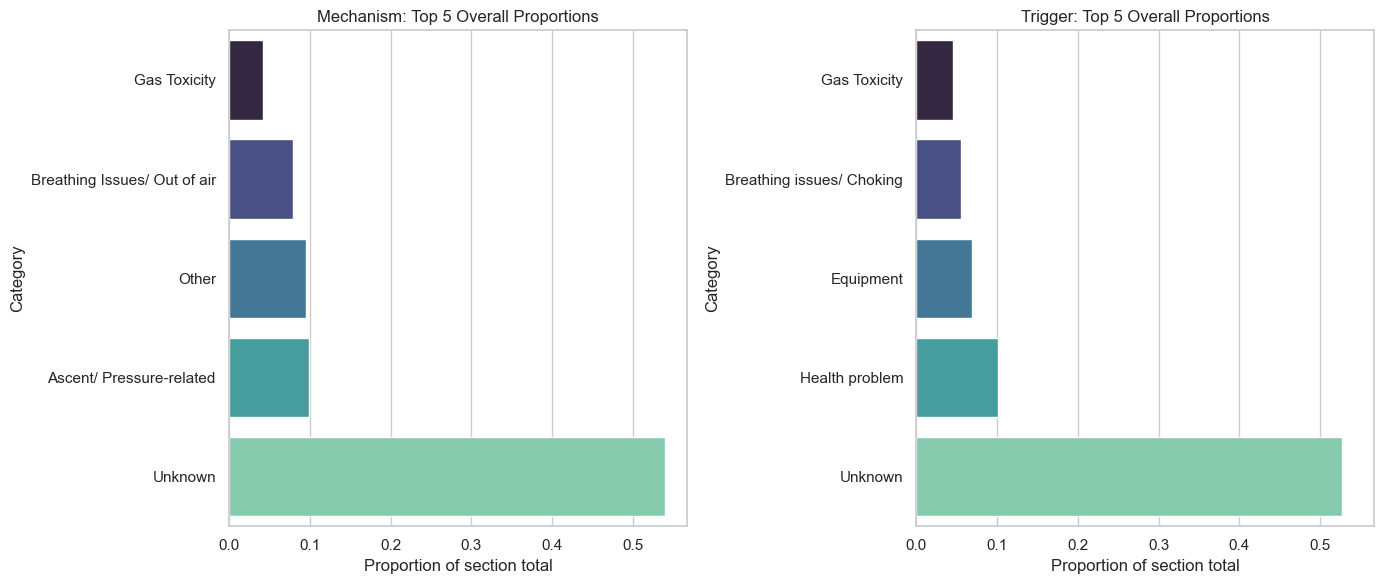

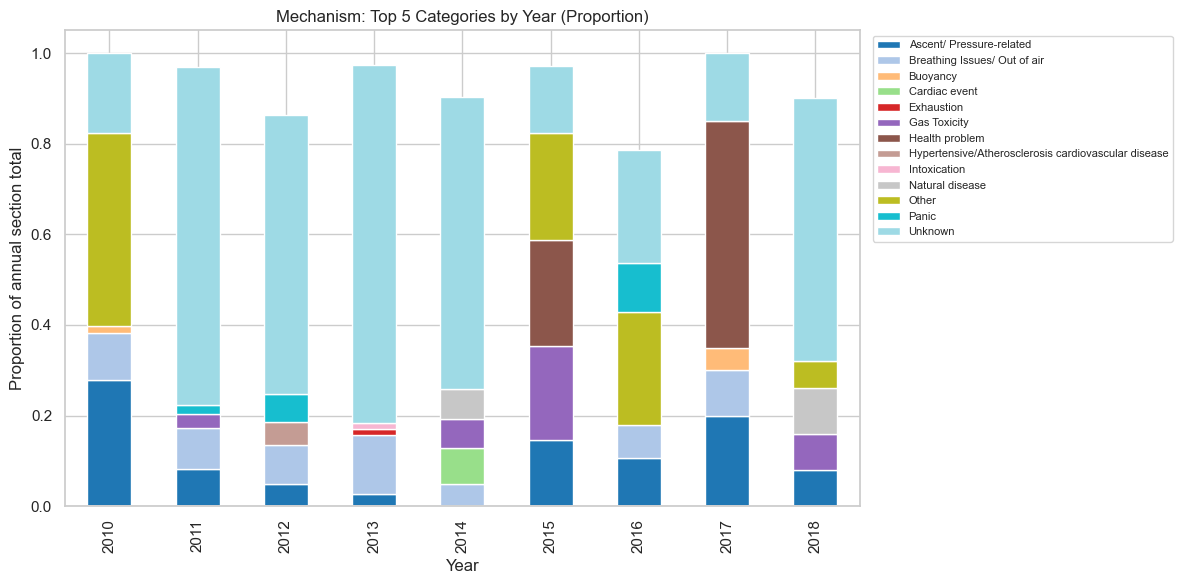

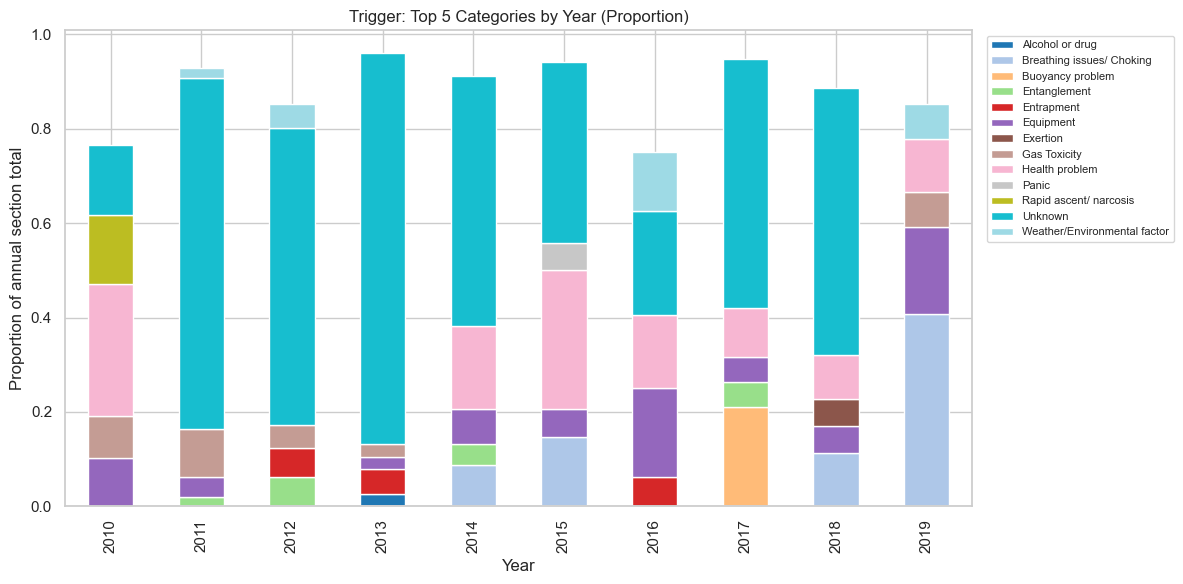

In [10]:
#Trigger + Mechanism analysis in a different cell: top 5 by yearly proportion and overall


## TODO Misspellings need to fix
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def _year_from_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, np.integer)):
        year = int(value)
        return year if 1900 <= year <= 2100 else None
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        year = int(value)
        return year if 1900 <= year <= 2100 else None
    text = str(value).strip()
    match = re.fullmatch(r"(\d{4})(?:\.0+)?", text)
    if match:
        year = int(match.group(1))
        return year if 1900 <= year <= 2100 else None
    return None

def parse_wide_section_table(df, section_name):
    raw = df.copy().dropna(how="all").reset_index(drop=True)
    raw.columns = [str(c).strip() for c in raw.columns]

    header_idx = None
    year_cols = {}
    for ridx in range(min(12, len(raw))):
        candidate = {}
        for cidx, val in raw.iloc[ridx].items():
            y = _year_from_value(val)
            if y is not None:
                candidate[cidx] = y
        if len(candidate) >= 3:
            header_idx = ridx
            year_cols = candidate
            break

    if header_idx is None:
        raise ValueError(f"Could not detect year header row for {section_name}")

    rows = []
    for ridx in range(header_idx + 1, len(raw)):
        category = raw.iloc[ridx, 0]
        if pd.isna(category):
            continue
        category = str(category).strip()
        if not category or category.lower() in {"total", "nan"}:
            continue
        for cidx, year in year_cols.items():
            value = pd.to_numeric(raw.loc[ridx, cidx], errors="coerce")
            if pd.isna(value):
                continue
            rows.append({
                "section": section_name,
                "category": category,
                "year": int(year),
                "count": float(value),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError(f"No usable rows parsed for {section_name}")
    return out

mechanism_long_2 = parse_wide_section_table(mechanisms, "Mechanism")
trigger_long_2 = parse_wide_section_table(triggers, "Trigger")
tm_long = pd.concat([mechanism_long_2, trigger_long_2], ignore_index=True)

#Yearly proportions
year_totals_tm = tm_long.groupby(["section", "year"], as_index=False)["count"].sum().rename(columns={"count": "year_total"})
tm_year_prop = tm_long.merge(year_totals_tm, on=["section", "year"], how="left")
tm_year_prop["proportion"] = np.where(tm_year_prop["year_total"] > 0, tm_year_prop["count"] / tm_year_prop["year_total"], 0)

top5_yearly = (
    tm_year_prop.sort_values(["section", "year", "proportion"], ascending=[True, True, False])
    .groupby(["section", "year"], as_index=False)
    .head(5)
)
print("Top 5 categories by proportion for each year and section:")
display(top5_yearly[["section", "year", "category", "proportion"]].sort_values(["section", "year", "proportion"], ascending=[True, True, False]))

#Overall proportions
overall_totals_tm = tm_long.groupby("section", as_index=False)["count"].sum().rename(columns={"count": "overall_total"})
tm_overall = tm_long.groupby(["section", "category"], as_index=False)["count"].sum().merge(overall_totals_tm, on="section", how="left")
tm_overall["proportion"] = np.where(tm_overall["overall_total"] > 0, tm_overall["count"] / tm_overall["overall_total"], 0)
top5_overall = tm_overall.sort_values(["section", "proportion"], ascending=[True, False]).groupby("section", as_index=False).head(5)
print("Top 5 categories overall by section:")
display(top5_overall[["section", "category", "proportion"]].sort_values(["section", "proportion"], ascending=[True, False]))

##### TO DO: Remove Unknown and replace with proportions of total for others

## TO DO: clean up visualizations, 

#GRAPH: Overall top 5 proportions for Trigger and Mechanism
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for i, sec in enumerate(["Mechanism", "Trigger"]):
    sub = top5_overall[top5_overall["section"] == sec].sort_values("proportion", ascending=True)
    sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")
    axes[i].set_title(f"{sec}: Top 5 Overall Proportions")
    axes[i].set_xlabel("Proportion of section total")
    axes[i].set_ylabel("Category")
plt.tight_layout()
plt.show()

#GRAPH: Yearly top 5 proportions (stacked bars)
for sec in ["Mechanism", "Trigger"]:
    sub = top5_yearly[top5_yearly["section"] == sec].copy()
    pivot = sub.pivot_table(index="year", columns="category", values="proportion", aggfunc="sum", fill_value=0).sort_index()
    plt.figure(figsize=(12, 6))
    pivot.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab20")
    plt.title(f"{sec}: Top 5 Categories by Year (Proportion)")
    plt.xlabel("Year")
    plt.ylabel("Proportion of annual section total")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
#### NETWORK ANALYSIS SECTION ---------------------------------------

In [11]:
file_path_network = Path.home() / "Downloads" / "YearbyMechanisms.xlsx"
network_data = pd.read_excel(file_path_network)
print(network_data.head())
print(network_data.info())

   Trigger  Health problem Trigger  Gas Toxicity Trigger  EquipmentTrigger  \
0   2010.0                    19.0                   6.0               7.0   
1   2011.0                     0.0                  10.0               4.0   
2   2012.0                     0.0                   4.0               3.0   
3   2013.0                     0.0                   2.0               2.0   
4   2014.0                    12.0                   1.0               5.0   

   Entrapment  Weather/Environmental factor Trigger  Entanglement Trigger  \
0         1.0                                   4.0                   3.0   
1         1.0                                   2.0                   2.0   
2         5.0                                   4.0                   5.0   
3         4.0                                   1.0                   0.0   
4         1.0                                   1.0                   3.0   

   Rapid ascent Trigger  Panic Trigger  Breathing issues Trigger  ..

In [14]:
trigger_cols = [c for c in network_data.columns if "Trigger" in c]
mech_cols = [c for c in network_data.columns if "Mech" in c]
disable_cols = [c for c in network_data.columns if "Disable" in c]
cod_cols = [c for c in network_data.columns if "Cause" in c or "COD" in c]

network_data["trigger_total"] = network_data[trigger_cols].sum(axis=1)
network_data["disable_total"] = network_data[disable_cols].sum(axis=1)
network_data["mech_total"] = network_data[mech_cols].sum(axis=1)
network_data["cod_total"] = network_data[cod_cols].sum(axis=1)
network_data = network_data.rename(columns={"Trigger": "Year"})

print(network_data[["trigger_total", "disable_total", "mech_total", "cod_total"]])

    trigger_total  disable_total  mech_total  cod_total
0            53.0           49.0        27.0         59
1            23.0           60.0        25.0         66
2            25.0           42.0        29.0         49
3             9.0           28.0        16.0         34
4            30.0           41.0        22.0         44
5            21.0           23.0        21.0         30
6            21.0           24.0        14.0         32
7             9.0           16.0        17.0         19
8            23.0           34.0        18.0         26
9            27.0            0.0         0.0         38
10            0.0            0.0         0.0         79


In [15]:
mech_prop = network_data[mech_cols].div(network_data[mech_cols].sum(axis=1), axis=0)
disable_prop = network_data[disable_cols].div(network_data[disable_cols].sum(axis=1), axis=0)
cod_prop = network_data[cod_cols].div(network_data[cod_cols].sum(axis=1), axis=0)
trigger_prop = network_data[trigger_cols].div(network_data[trigger_cols].sum(axis=1), axis=0)
#proportions

In [16]:

trigger_prop["Year"] = network_data["Year"]
disable_prop["Year"] = network_data["Year"]
mech_prop["Year"] = network_data["Year"]
cod_prop["Year"] = network_data["Year"]

In [17]:
print(network_data.columns)

Index(['Year', 'Health problem Trigger', 'Gas Toxicity Trigger',
       'EquipmentTrigger', 'Entrapment',
       'Weather/Environmental factor Trigger', 'Entanglement Trigger',
       'Rapid ascent Trigger', 'Panic Trigger', 'Breathing issues Trigger',
       'Exertion Trigger', 'Alcohol or drug Trigger', 'Cardiac event Trigger',
       'Inexperience Trigger', 'Buoyancy problem Trigger', 'Cardiac Disable',
       'Drowning/ Asphixia Disable', 'Decompression/Pressure related Disable',
       'Immersion pulmonary edema Disable', 'Loss of consciousness Disable',
       'Seizure Disable', 'Intoxication Disable',
       'Carbon monoxide poisoning Disable', 'Shark bite Disable',
       'Respiratory distress Disable', 'Blunt head trauma Disable',
       'Stroke Disable', 'Other Health Issue Disable', 'Panic Disable',
       'Breathing Issues/ Out of air Mech', 'Panic Mech',
       'Ascent/ Pressure-related Mech', 'Exhaustion Mech',
       'Environmental Mech', 'Intoxication Mech', 'Striking a

In [18]:
#combined triggers cased on categories

###categories Medical, Human Behavior, Equipment, Environmental, Ascent/Buoyancy

network_data["Medical Trigger"] = (
    network_data["Health problem Trigger"] +
    network_data["Cardiac event Trigger"]
)

network_data["Human Behavior Trigger"] = (
    network_data["Panic Trigger"] +
    network_data["Inexperience Trigger"] +
    network_data["Alcohol or drug Trigger"] +
    network_data["Exertion Trigger"]
)

network_data["Equipment Trigger"] = (
    network_data["EquipmentTrigger"] +
    network_data["Breathing issues Trigger"] +
    network_data["Gas Toxicity Trigger"]
) 

network_data["Environmental Trigger"] = (
    network_data["Entrapment"] +
    network_data["Entanglement Trigger"]
)

network_data["Ascent / Buoyancy Trigger"] = (
    network_data["Buoyancy problem Trigger"] +
    network_data["Rapid ascent Trigger"]
)

In [19]:
#combined disabling factors based on categories

###categories Drowning/Respiratory, Cardiovascular/Neurological, Pressure Injury, Environmental, Human

network_data["Drowning / Respiratory Disabling"] = (
    network_data["Respiratory distress Disable"] +
     network_data["Drowning/ Asphixia Disable"] +
     network_data["Immersion pulmonary edema Disable"]
)

network_data["Cardiovascular / Neurological Disabling"] = (
    network_data["Cardiac Disable"] +
    network_data["Stroke Disable"] +
    network_data["Loss of consciousness Disable"] +
    network_data["Seizure Disable"] +
    network_data["Other Health Issue Disable"]
)

network_data["Pressure Injury Disabling"] = (
    network_data["Decompression/Pressure related Disable"]
)
network_data["Environmental Disabling"] = (
    network_data["Blunt head trauma Disable"] +
    network_data["Shark bite Disable"] +
    network_data["Carbon monoxide poisoning Disable"]
    
)
network_data["Human Disabling"] = (
    network_data["Panic Disable"] +
    network_data["Intoxication Disable"]
)

In [20]:
##Mechanism categories: Gas/Breathing, Panic/Human, Pressure/Ascent, Medical, Environmental/Impact
#combined mechanisms based on categories

network_data["Gas / Breathing Mechanism"] = (
    network_data["Breathing Issues/ Out of air Mech"] +
    network_data["Gas Toxicity Mech"]
)

network_data["Human Behavior Mechanism"] = (
    network_data["Panic Mech"] +
    network_data["Exhaustion Mech"] +
    network_data["Intoxication Mech"] 
)
network_data["Pressure / Ascent Mechanism"] = (
    network_data["Ascent/ Pressure-related Mech"] +
    network_data["Buoyancy Mech"]
)
network_data["Medical Mechanism"] = (
    network_data["Health problem Mech"] +
    network_data["Stroke Mech"] +
    network_data["Cardiac event Mech"]
)
network_data["Enviromental / Equipment Mechanism"] = (
    network_data["Environmental Mech"] +
    network_data["Striking an object Mech"] +
    network_data["Entangled Mech"] +
    network_data["Equipment Mech"]
)



In [29]:
#cause of death
##categories Drowning, Cardiac/Heart, Pressure Injury, Trauma/Toxic, Environmental  

network_data["Drowning Cause"] = (
        network_data["Drowning Cause"] +
        network_data["Respiratory issue Cause"] +
        network_data["Immersion pulmonary edema Cause"]
)
network_data["Cardiac/Heart Cause"] = (
    network_data["Cardiac/Heart Issue Cause"]
)
network_data["Pressure Injury Cause"] = (
    network_data["Decompression/Pressure related Cause"]
)
network_data["Trauma / Toxic Cause"] = (
    network_data["Head/brain injury Cause"] +
    network_data["Carbon monoxide poisoning Cause"] +
    network_data["Intoxication Cause"]
)
network_data["Environmental Cause"] = (
    network_data["Shark bite Cause"] +
    network_data["bite venom Cause"] +
    network_data["Entanglement Cause"] +
    network_data["Adverse cons Cause"]
)   

    

In [14]:
# Analysis
import networkx as nx
import numpy as np
import pandas as pd

stage_groups = {
    "Trigger": [
        "Medical Trigger",
        "Human Behavior Trigger",
        "Equipment Trigger",
        "Environmental Trigger",
        "Ascent / Buoyancy Trigger",
    ],
    "Mechanism": [
        "Gas / Breathing Mechanism",
        "Human Behavior Mechanism",
        "Pressure / Ascent Mechanism",
        "Medical Mechanism",
        "Enviromental / Equipment Mechanism",
    ],
    "Disabling": [
        "Drowning / Respiratory Disabling",
        "Cardiovascular / Neurological Disabling",
        "Pressure Injury Disabling",
        "Environmental Disabling",
        "Human Disabling",
    ],
    "Cause": [
        "Drowning Cause",
        "Cardiac/Heart Cause",
        "Pressure Injury Cause",
        "Trauma / Toxic Cause",
        "Environmental Cause",
    ],
}

stage_order = ["Trigger", "Mechanism", "Disabling", "Cause"]
missing_cols = {
    stage: [col for col in cols if col not in network_data.columns]
    for stage, cols in stage_groups.items()
    if any(col not in network_data.columns for col in cols)
}
if missing_cols:
    raise KeyError(f"Missing grouped columns needed for network analysis: {missing_cols}")


def build_stage_share_table(df, cols):
    temp = df[["Year"] + cols].copy()
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")
    temp = temp.dropna(subset=["Year"]).copy()
    temp["Year"] = temp["Year"].astype(int)
    temp[cols] = temp[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    temp = temp.groupby("Year", as_index=False)[cols].sum()
    temp["stage_total"] = temp[cols].sum(axis=1)
    shares = temp[["Year"]].copy()
    denom = temp["stage_total"].replace(0, np.nan)
    for col in cols:
        shares[col] = (temp[col] / denom).fillna(0)
    return shares, temp.set_index("Year")["stage_total"]


stage_share_tables = {}
stage_total_series = {}
for stage, cols in stage_groups.items():
    share_table, total_series = build_stage_share_table(network_data, cols)
    stage_share_tables[stage] = share_table
    stage_total_series[stage] = total_series

print("Trigger stage shares:")
display(stage_share_tables["Trigger"].head())

Trigger stage shares:


,Year,Medical Trigger,Human Behavior Trigger,Equipment Trigger,Environmental Trigger,Ascent / Buoyancy Trigger
0,2010,0.400000,0.040000,0.260000,0.080000,0.220000
1,2011,0.000000,0.136364,0.681818,0.136364,0.045455
2,2012,0.076923,0.230769,0.269231,0.384615,0.038462
3,2013,0.000000,0.250000,0.333333,0.333333,0.083333
4,2014,0.400000,0.066667,0.400000,0.133333,0.000000


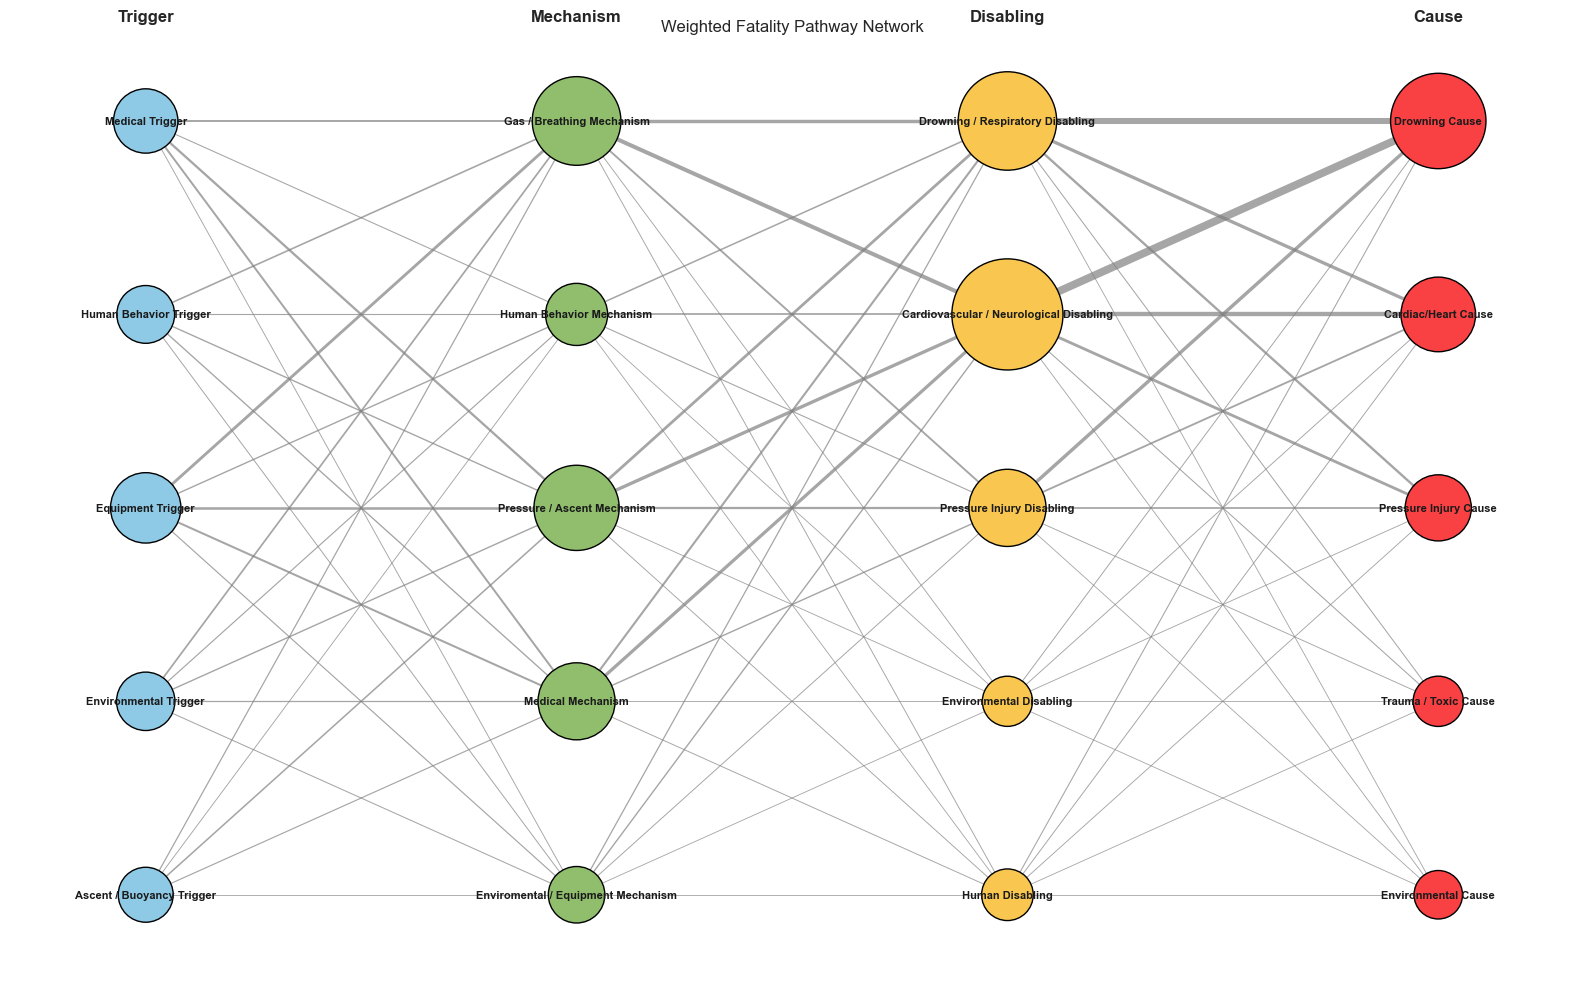

In [31]:
import matplotlib.pyplot as plt

# Layered visualization
plt.figure(figsize=(16, 10))
ax = plt.gca()

stage_x = {"Trigger": 0, "Mechanism": 3, "Disabling": 6, "Cause": 9}
node_pos = {}
for stage, cols in stage_groups.items():
    y_positions = np.linspace(1.0, -1.0, len(cols))
    for y, node in zip(y_positions, cols):
        node_pos[node] = (stage_x[stage], y)

stage_colors = {
    "Trigger": "#8ecae6",
    "Mechanism": "#90be6d",
    "Disabling": "#f9c74f",
    "Cause": "#f94144",
}

strength_lookup = metrics.set_index("node")["strength"].to_dict()
max_strength = max(strength_lookup.values()) if strength_lookup else 1.0

for stage, cols in stage_groups.items():
    nx.draw_networkx_nodes(
        G,
        node_pos,
        nodelist=cols,
        node_color=stage_colors[stage],
        node_size=[1200 + 5200 * (strength_lookup.get(node, 0) / max_strength) for node in cols],
        edgecolors="black",
        linewidths=1.0,
        ax=ax,
    )

nx.draw_networkx_labels(G, node_pos, font_size=8, font_weight="bold", ax=ax)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_weight = max(edge_weights) if edge_weights else 1.0
widths = [0.6 + 5.0 * (w / max_weight) for w in edge_weights]

nx.draw_networkx_edges(
    G,
    node_pos,
    width=widths,
    edge_color="gray",
    alpha=0.7,
    arrows=False,
    ax=ax,
)

for stage, x in stage_x.items():
    ax.text(x, 1.25, stage, ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Weighted Fatality Pathway Network")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [32]:
##NODES AND EDGES METRICS

from networkx.algorithms.community import greedy_modularity_communities

# Build edges first
def build_layer_edges(source_stage, target_stage):
    source_cols = stage_groups[source_stage]
    target_cols = stage_groups[target_stage]

    source = stage_share_tables[source_stage].set_index("Year")
    target = stage_share_tables[target_stage].set_index("Year")
    years = sorted(set(source.index).intersection(target.index))

    rows = []
    for year in years:
        srow = source.loc[year, source_cols]
        trow = target.loc[year, target_cols]
        source_scale = float(stage_total_series[source_stage].loc[year])
        target_scale = float(stage_total_series[target_stage].loc[year])
        pair_scale = (source_scale + target_scale) / 2.0

        if pair_scale <= 0:
            continue

        for source_node in source_cols:
            for target_node in target_cols:
                weight = float(srow[source_node]) * float(trow[target_node]) * pair_scale
                if weight > 0:
                    rows.append(
                        {
                            "source": source_node,
                            "target": target_node,
                            "weight": weight,
                            "year": year,
                            "stage_pair": f"{source_stage} → {target_stage}",
                        }
                    )

    return pd.DataFrame(rows)


edge_df_parts = [
    build_layer_edges("Trigger", "Mechanism"),
    build_layer_edges("Mechanism", "Disabling"),
    build_layer_edges("Disabling", "Cause"),
]

edge_df = pd.concat(edge_df_parts, ignore_index=True)
edge_df = (
    edge_df.groupby(["source", "target", "stage_pair"], as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
)

# Now build the graph
G = nx.DiGraph()
for _, row in edge_df.iterrows():
    G.add_edge(row["source"], row["target"], weight=float(row["weight"]))

node_stage = {
    node: stage
    for stage, cols in stage_groups.items()
    for node in cols
}
nx.set_node_attributes(G, node_stage, "stage")

metrics = pd.DataFrame({"node": list(G.nodes())})
metrics["stage"] = metrics["node"].map(node_stage)
metrics["in_strength"] = metrics["node"].apply(
    lambda node: sum(data["weight"] for _, _, data in G.in_edges(node, data=True))
)
metrics["out_strength"] = metrics["node"].apply(
    lambda node: sum(data["weight"] for _, _, data in G.out_edges(node, data=True))
)
metrics["strength"] = metrics["in_strength"] + metrics["out_strength"]

if G.number_of_edges() > 0:
    metrics["pagerank"] = metrics["node"].map(nx.pagerank(G, weight="weight"))
    undirected_G = G.to_undirected()
    distance_G = undirected_G.copy()
    for u, v, data in distance_G.edges(data=True):
        data["distance"] = 1.0 / data["weight"] if data["weight"] > 0 else 1.0
    metrics["betweenness"] = metrics["node"].map(
        nx.betweenness_centrality(distance_G, weight="distance")
    )
    communities = list(greedy_modularity_communities(undirected_G, weight="weight"))
    community_lookup = {
        node: f"C{i + 1}"
        for i, community in enumerate(communities)
        for node in community
    }
    metrics["community"] = metrics["node"].map(community_lookup)
else:
    metrics["pagerank"] = 0
    metrics["betweenness"] = 0
    metrics["community"] = None

metrics = metrics.sort_values(["stage", "strength"], ascending=[True, False])

###NODE METRICS
print("Node metrics:")
display(metrics)
#Top nodes by PAGERANK
print("Top nodes by PageRank")
display(metrics.sort_values("pagerank", ascending=False).head(10))

#TOP PATHWAY EDGES
print("Top pathway edges:")
display(edge_df.head(15))

Node metrics:


,node,stage,in_strength,out_strength,strength,pagerank,betweenness,community
1,Drowning Cause,Cause,201.136188,0.000000,201.136188,0.173310,0.315789,C2
3,Cardiac/Heart Cause,Cause,89.132048,0.000000,89.132048,0.091551,0.000000,C2
10,Pressure Injury Cause,Cause,40.947327,0.000000,40.947327,0.053723,0.000000,C2
17,Trauma / Toxic Cause,Cause,5.829891,0.000000,5.829891,0.027579,0.000000,C2
19,Environmental Cause,Cause,0.954545,0.000000,0.954545,0.023986,0.000000,C2
0,Cardiovascular / Neurological Disabling,Disabling,117.979730,156.510060,274.489790,0.109204,0.742690,C2
2,Drowning / Respiratory Disabling,Disabling,85.755022,116.087518,201.842539,0.085534,0.000000,C2
5,Pressure Injury Disabling,Disabling,42.637335,56.970893,99.608229,0.052734,0.000000,C2
16,Human Disabling,Disabling,4.306049,5.261610,9.567659,0.026300,0.000000,C1
18,Environmental Disabling,Disabling,2.321864,3.169919,5.491783,0.025036,0.000000,C1


Top nodes by PageRank


,node,stage,in_strength,out_strength,strength,pagerank,betweenness,community
1,Drowning Cause,Cause,201.136188,0.000000,201.136188,0.173310,0.315789,C2
0,Cardiovascular / Neurological Disabling,Disabling,117.979730,156.510060,274.489790,0.109204,0.742690,C2
3,Cardiac/Heart Cause,Cause,89.132048,0.000000,89.132048,0.091551,0.000000,C2
2,Drowning / Respiratory Disabling,Disabling,85.755022,116.087518,201.842539,0.085534,0.000000,C2
4,Gas / Breathing Mechanism,Mechanism,64.917411,86.851976,151.769387,0.054938,0.245614,C1
6,Pressure / Ascent Mechanism,Mechanism,61.741010,73.643023,135.384033,0.054632,0.181287,C1
10,Pressure Injury Cause,Cause,40.947327,0.000000,40.947327,0.053723,0.000000,C2
5,Pressure Injury Disabling,Disabling,42.637335,56.970893,99.608229,0.052734,0.000000,C2
7,Medical Mechanism,Mechanism,44.677536,54.435046,99.112582,0.044943,0.000000,C1
11,Human Behavior Mechanism,Mechanism,18.315550,23.909442,42.224992,0.032329,0.000000,C1


Top pathway edges:


,source,target,stage_pair,weight
6,Cardiovascular / Neurological Disabling,Drowning Cause,Disabling → Cause,92.432598
11,Drowning / Respiratory Disabling,Drowning Cause,Disabling → Cause,69.802676
5,Cardiovascular / Neurological Disabling,Cardiac/Heart Cause,Disabling → Cause,43.568995
35,Gas / Breathing Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,39.445442
71,Pressure Injury Disabling,Drowning Cause,Disabling → Cause,34.119713
36,Gas / Breathing Mechanism,Drowning / Respiratory Disabling,Mechanism → Disabling,31.958941
65,Pressure / Ascent Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,30.662706
10,Drowning / Respiratory Disabling,Cardiac/Heart Cause,Disabling → Cause,30.366526
55,Medical Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,29.576789
31,Equipment Trigger,Gas / Breathing Mechanism,Trigger → Mechanism,25.183379


In [33]:
#PATHWAYS

def build_layer_edges(source_stage, target_stage):
    source_cols = stage_groups[source_stage]
    target_cols = stage_groups[target_stage]

    source = stage_share_tables[source_stage].set_index("Year")
    target = stage_share_tables[target_stage].set_index("Year")
    years = sorted(set(source.index).intersection(target.index))

    rows = []
    for year in years:
        srow = source.loc[year, source_cols]
        trow = target.loc[year, target_cols]
        source_scale = float(stage_total_series[source_stage].loc[year])
        target_scale = float(stage_total_series[target_stage].loc[year])
        pair_scale = (source_scale + target_scale) / 2.0

        if pair_scale <= 0:
            continue

        for source_node in source_cols:
            for target_node in target_cols:
                weight = float(srow[source_node]) * float(trow[target_node]) * pair_scale
                if weight > 0:
                    rows.append(
                        {
                            "source": source_node,
                            "target": target_node,
                            "weight": weight,
                            "year": year,
                            "stage_pair": f"{source_stage} → {target_stage}",
                        }
                    )

    return pd.DataFrame(rows)


edge_df_parts = [
    build_layer_edges("Trigger", "Mechanism"),
    build_layer_edges("Mechanism", "Disabling"),
    build_layer_edges("Disabling", "Cause"),
]

edge_df = pd.concat(edge_df_parts, ignore_index=True)
edge_df = (
    edge_df.groupby(["source", "target", "stage_pair"], as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
)

#TOP PATHWAY EDGES
display(edge_df.head(15))

,source,target,stage_pair,weight
6,Cardiovascular / Neurological Disabling,Drowning Cause,Disabling → Cause,92.432598
11,Drowning / Respiratory Disabling,Drowning Cause,Disabling → Cause,69.802676
5,Cardiovascular / Neurological Disabling,Cardiac/Heart Cause,Disabling → Cause,43.568995
35,Gas / Breathing Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,39.445442
71,Pressure Injury Disabling,Drowning Cause,Disabling → Cause,34.119713
36,Gas / Breathing Mechanism,Drowning / Respiratory Disabling,Mechanism → Disabling,31.958941
65,Pressure / Ascent Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,30.662706
10,Drowning / Respiratory Disabling,Cardiac/Heart Cause,Disabling → Cause,30.366526
55,Medical Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,29.576789
31,Equipment Trigger,Gas / Breathing Mechanism,Trigger → Mechanism,25.183379


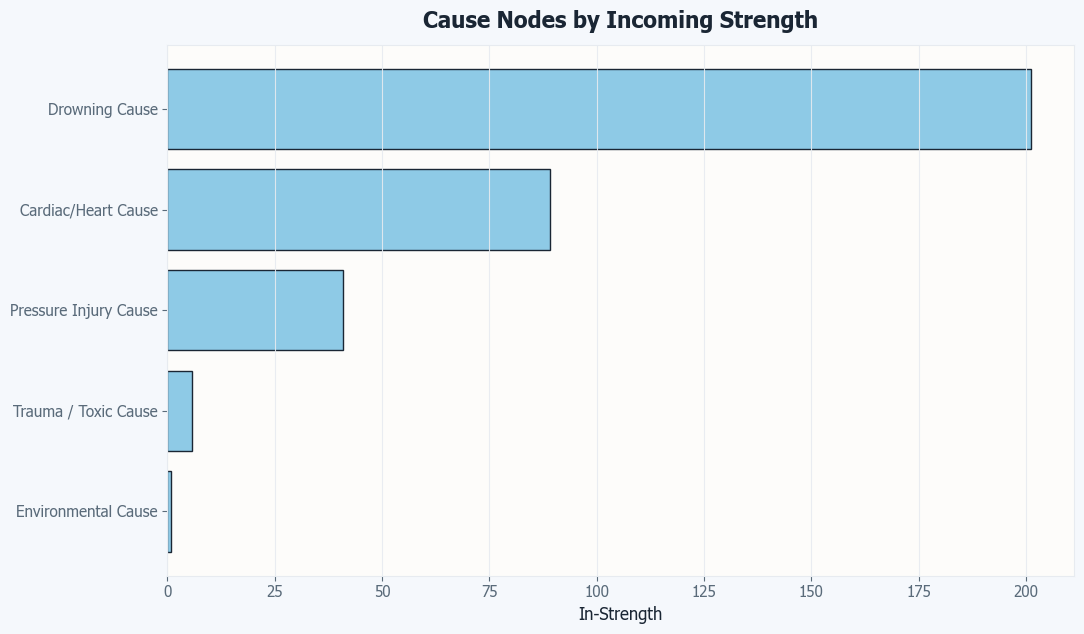

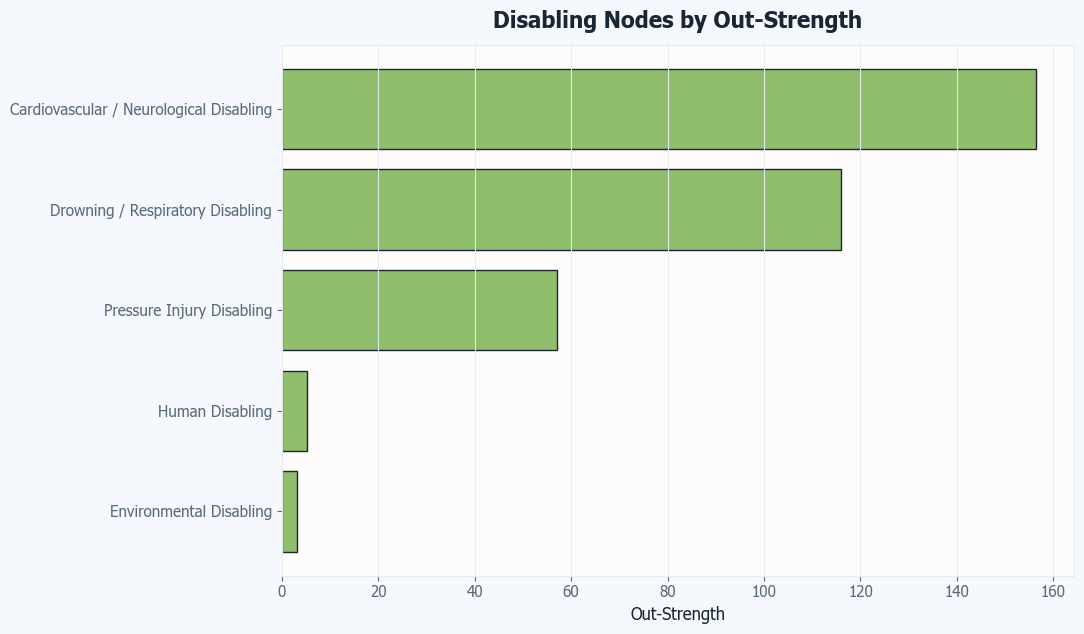

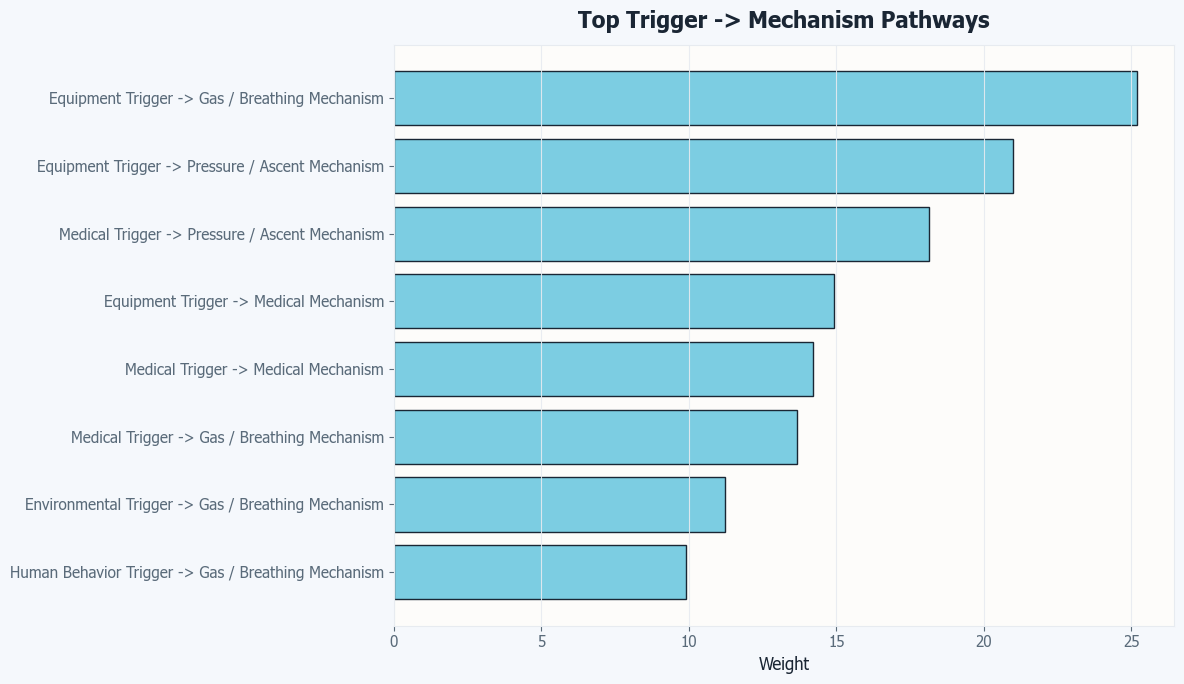

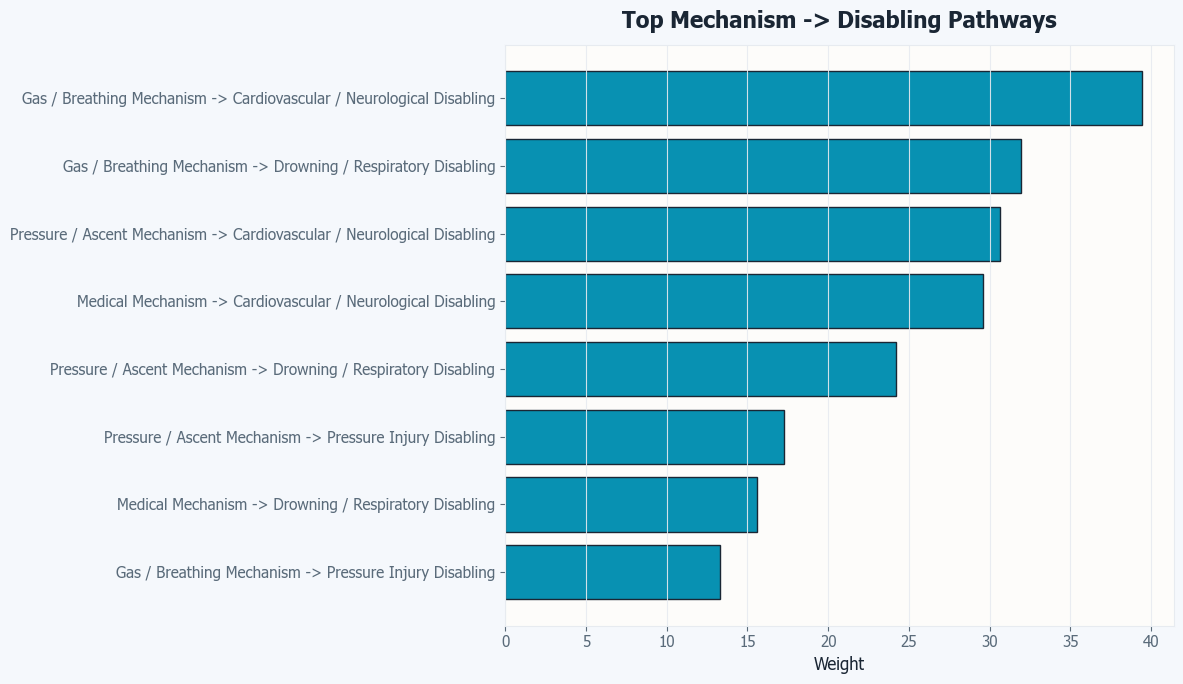

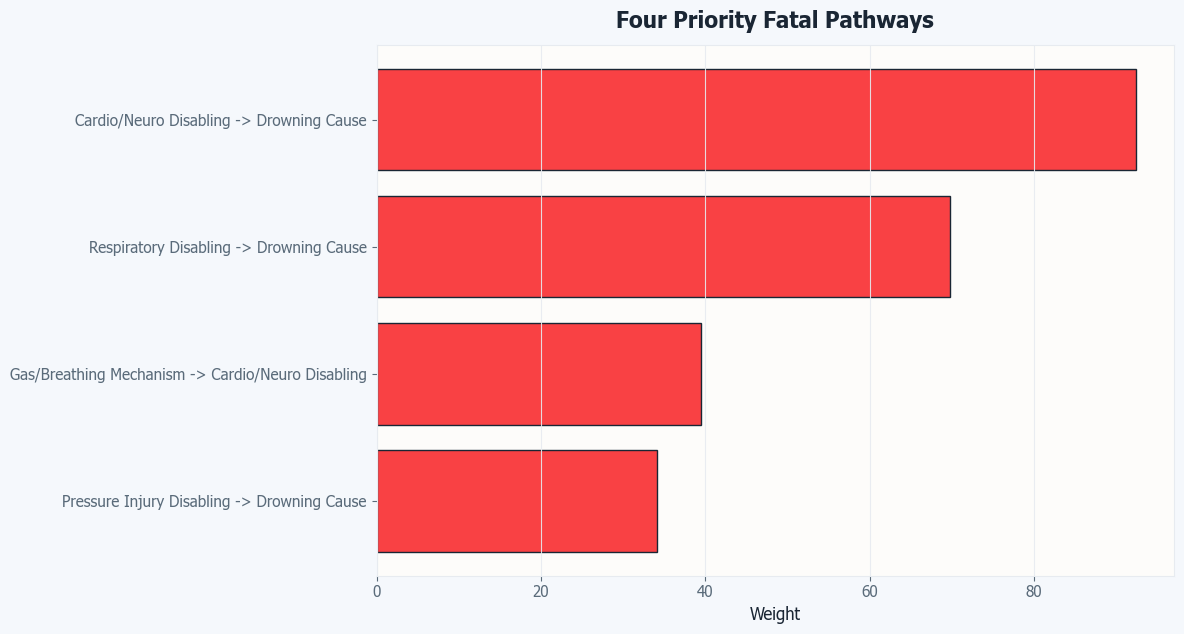

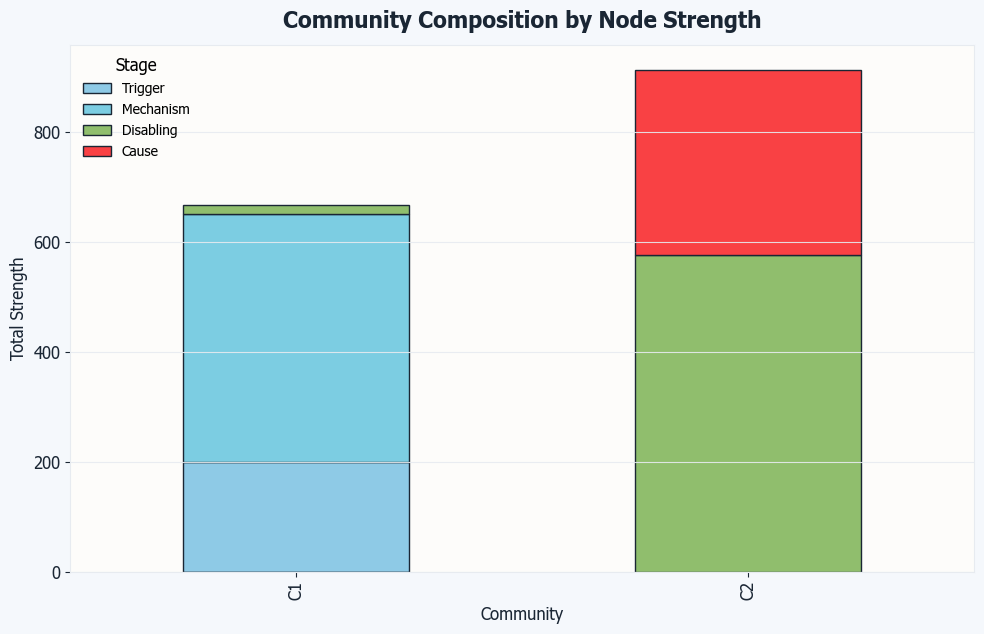

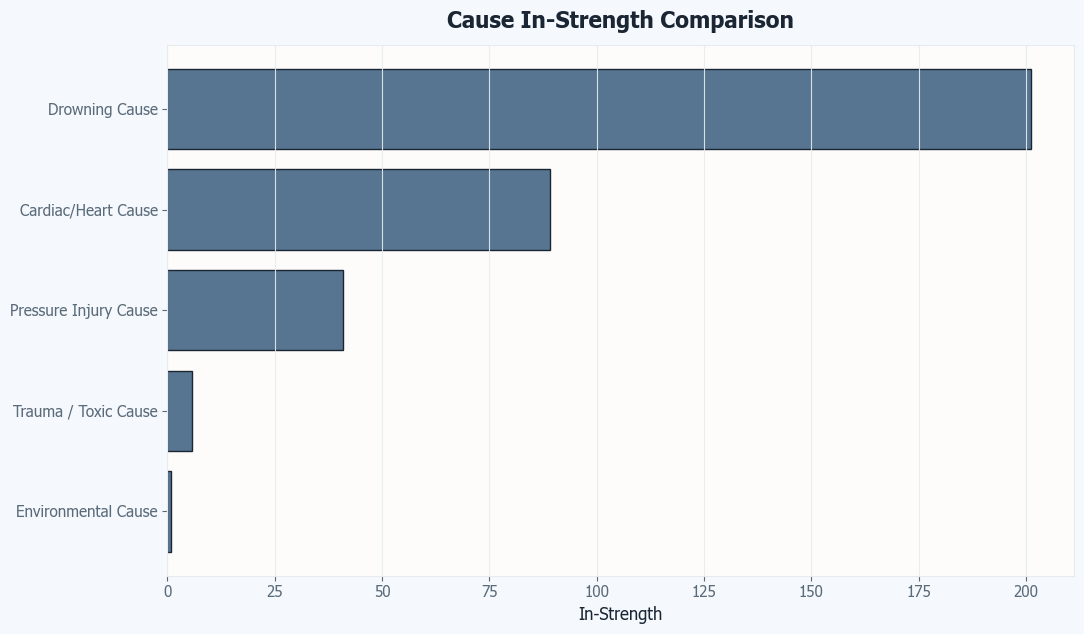

,stage_pair,path,weight
6,Disabling → Cause,Cardiovascular / Neurological Disabling -> Dro...,92.432598
11,Disabling → Cause,Drowning / Respiratory Disabling -> Drowning C...,69.802676
5,Disabling → Cause,Cardiovascular / Neurological Disabling -> Car...,43.568995
35,Mechanism → Disabling,Gas / Breathing Mechanism -> Cardiovascular / ...,39.445442
71,Disabling → Cause,Pressure Injury Disabling -> Drowning Cause,34.119713
36,Mechanism → Disabling,Gas / Breathing Mechanism -> Drowning / Respir...,31.958941
65,Mechanism → Disabling,Pressure / Ascent Mechanism -> Cardiovascular ...,30.662706
10,Disabling → Cause,Drowning / Respiratory Disabling -> Cardiac/He...,30.366526
55,Mechanism → Disabling,Medical Mechanism -> Cardiovascular / Neurolog...,29.576789
31,Trigger → Mechanism,Equipment Trigger -> Gas / Breathing Mechanism,25.183379


Exported chart images to: /Users/mirandagrein/Documents/final project/figures/network-analysis


In [7]:
# ADDITIONAL VISUALIZATIONS TO SUPPORT NETWORK FINDINGS (keeps existing node viz unchanged)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from networkx.algorithms.community import greedy_modularity_communities

# ------------------------------------------------------------------
# Index-style theme + export helpers
# ------------------------------------------------------------------
THEME = {
    "bg": "#f5f8fc",
    "panel": "#fdfcfa",
    "panel_soft": "#fbfbf7",
    "line": "#e7ebf0",
    "text": "#1a2634",
    "muted": "#5a6b7a",
    "accent": "#0891b2",
    "accent_soft": "#dff4fb",
    "trigger": "#8ecae6",
    "mechanism": "#7ccde2",
    "disabling": "#90be6d",
    "cause": "#f94144",
    "alt": "#577590",
}

plt.rcParams.update({
    "figure.facecolor": THEME["bg"],
    "axes.facecolor": THEME["panel"],
    "axes.edgecolor": THEME["line"],
    "axes.labelcolor": THEME["text"],
    "axes.titlecolor": THEME["text"],
    "xtick.color": THEME["text"],
    "ytick.color": THEME["text"],
    "font.size": 12,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Tahoma", "Geneva", "Verdana", "Arial", "DejaVu Sans"],
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
})

# Saves to project-level folder used by findings.html
export_dir = Path.cwd() / "figures" / "network-analysis"
export_dir.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, filename):
    fig.savefig(export_dir / filename, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


def style_axis(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel, color=THEME["text"])
    ax.set_ylabel(ylabel, color=THEME["text"])
    ax.tick_params(axis="both", colors=THEME["muted"], labelsize=11)
    ax.grid(axis="x", color=THEME["line"], alpha=0.9, linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color(THEME["line"])


# ------------------------------------------------------------------
# Robust setup: load/build what is needed if user runs this cell alone
# ------------------------------------------------------------------
if "network_data" not in globals():
    file_path_network = Path.home() / "Downloads" / "YearbyMechanisms.xlsx"
    if not file_path_network.exists():
        raise RuntimeError("Could not find YearbyMechanisms.xlsx in Downloads.")
    network_data = pd.read_excel(file_path_network)

if "Year" not in network_data.columns and "Trigger" in network_data.columns:
    network_data = network_data.rename(columns={"Trigger": "Year"})


def safe_sum(df, cols):
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series(0, index=df.index, dtype=float)
    return df[present].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)


def ensure_grouped_columns(df):
    if "Medical Trigger" not in df.columns:
        df["Medical Trigger"] = safe_sum(df, ["Health problem Trigger", "Cardiac event Trigger"])
    if "Human Behavior Trigger" not in df.columns:
        df["Human Behavior Trigger"] = safe_sum(df, [
            "Panic Trigger", "Inexperience Trigger", "Alcohol or drug Trigger", "Exertion Trigger"
        ])
    if "Equipment Trigger" not in df.columns:
        df["Equipment Trigger"] = safe_sum(df, ["EquipmentTrigger", "Breathing issues Trigger", "Gas Toxicity Trigger"])
    if "Environmental Trigger" not in df.columns:
        df["Environmental Trigger"] = safe_sum(df, ["Entrapment", "Entanglement Trigger"])
    if "Ascent / Buoyancy Trigger" not in df.columns:
        df["Ascent / Buoyancy Trigger"] = safe_sum(df, ["Buoyancy problem Trigger", "Rapid ascent Trigger"])

    if "Gas / Breathing Mechanism" not in df.columns:
        df["Gas / Breathing Mechanism"] = safe_sum(df, ["Breathing Issues/ Out of air Mech", "Gas Toxicity Mech"])
    if "Human Behavior Mechanism" not in df.columns:
        df["Human Behavior Mechanism"] = safe_sum(df, ["Panic Mech", "Exhaustion Mech", "Intoxication Mech"])
    if "Pressure / Ascent Mechanism" not in df.columns:
        df["Pressure / Ascent Mechanism"] = safe_sum(df, ["Ascent/ Pressure-related Mech", "Buoyancy Mech"])
    if "Medical Mechanism" not in df.columns:
        df["Medical Mechanism"] = safe_sum(df, ["Health problem Mech", "Stroke Mech", "Cardiac event Mech"])
    if "Enviromental / Equipment Mechanism" not in df.columns:
        df["Enviromental / Equipment Mechanism"] = safe_sum(df, ["Environmental Mech", "Striking an object Mech", "Entangled Mech", "Equipment Mech"])

    if "Drowning / Respiratory Disabling" not in df.columns:
        df["Drowning / Respiratory Disabling"] = safe_sum(df, ["Respiratory distress Disable", "Drowning/ Asphixia Disable", "Immersion pulmonary edema Disable"])
    if "Cardiovascular / Neurological Disabling" not in df.columns:
        df["Cardiovascular / Neurological Disabling"] = safe_sum(df, ["Cardiac Disable", "Stroke Disable", "Loss of consciousness Disable", "Seizure Disable", "Other Health Issue Disable"])
    if "Pressure Injury Disabling" not in df.columns:
        df["Pressure Injury Disabling"] = safe_sum(df, ["Decompression/Pressure related Disable"])
    if "Environmental Disabling" not in df.columns:
        df["Environmental Disabling"] = safe_sum(df, ["Blunt head trauma Disable", "Shark bite Disable", "Carbon monoxide poisoning Disable"])
    if "Human Disabling" not in df.columns:
        df["Human Disabling"] = safe_sum(df, ["Panic Disable", "Intoxication Disable"])

    if "Drowning Cause" not in df.columns or "Respiratory issue Cause" in df.columns:
        drowning_base = pd.to_numeric(df.get("Drowning Cause", 0), errors="coerce").fillna(0)
        df["Drowning Cause"] = drowning_base + safe_sum(df, ["Respiratory issue Cause", "Immersion pulmonary edema Cause"])
    if "Cardiac/Heart Cause" not in df.columns:
        df["Cardiac/Heart Cause"] = safe_sum(df, ["Cardiac/Heart Issue Cause"])
    if "Pressure Injury Cause" not in df.columns:
        df["Pressure Injury Cause"] = safe_sum(df, ["Decompression/Pressure related Cause"])
    if "Trauma / Toxic Cause" not in df.columns:
        df["Trauma / Toxic Cause"] = safe_sum(df, ["Head/brain injury Cause", "Carbon monoxide poisoning Cause", "Intoxication Cause"])
    if "Environmental Cause" not in df.columns:
        df["Environmental Cause"] = safe_sum(df, ["Shark bite Cause", "bite venom Cause", "Entanglement Cause", "Adverse cons Cause"])


ensure_grouped_columns(network_data)

if "stage_groups" not in globals():
    stage_groups = {
        "Trigger": [
            "Medical Trigger",
            "Human Behavior Trigger",
            "Equipment Trigger",
            "Environmental Trigger",
            "Ascent / Buoyancy Trigger",
        ],
        "Mechanism": [
            "Gas / Breathing Mechanism",
            "Human Behavior Mechanism",
            "Pressure / Ascent Mechanism",
            "Medical Mechanism",
            "Enviromental / Equipment Mechanism",
        ],
        "Disabling": [
            "Drowning / Respiratory Disabling",
            "Cardiovascular / Neurological Disabling",
            "Pressure Injury Disabling",
            "Environmental Disabling",
            "Human Disabling",
        ],
        "Cause": [
            "Drowning Cause",
            "Cardiac/Heart Cause",
            "Pressure Injury Cause",
            "Trauma / Toxic Cause",
            "Environmental Cause",
        ],
    }

if "metrics" not in globals() or "edge_df" not in globals():
    missing_cols = {
        stage: [col for col in cols if col not in network_data.columns]
        for stage, cols in stage_groups.items()
        if any(col not in network_data.columns for col in cols)
    }
    if missing_cols:
        raise RuntimeError(f"Missing grouped columns in network_data: {missing_cols}")

    def build_stage_share_table(df, cols):
        temp = df[["Year"] + cols].copy()
        temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")
        temp = temp.dropna(subset=["Year"]).copy()
        temp["Year"] = temp["Year"].astype(int)
        temp[cols] = temp[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
        temp = temp.groupby("Year", as_index=False)[cols].sum()
        temp["stage_total"] = temp[cols].sum(axis=1)
        shares = temp[["Year"]].copy()
        denom = temp["stage_total"].replace(0, np.nan)
        for col in cols:
            shares[col] = (temp[col] / denom).fillna(0)
        return shares, temp.set_index("Year")["stage_total"]

    stage_share_tables = {}
    stage_total_series = {}
    for stage, cols in stage_groups.items():
        share_table, total_series = build_stage_share_table(network_data, cols)
        stage_share_tables[stage] = share_table
        stage_total_series[stage] = total_series

    def build_layer_edges(source_stage, target_stage):
        source_cols = stage_groups[source_stage]
        target_cols = stage_groups[target_stage]

        source = stage_share_tables[source_stage].set_index("Year")
        target = stage_share_tables[target_stage].set_index("Year")
        years = sorted(set(source.index).intersection(target.index))

        rows = []
        for year in years:
            srow = source.loc[year, source_cols]
            trow = target.loc[year, target_cols]
            source_scale = float(stage_total_series[source_stage].loc[year])
            target_scale = float(stage_total_series[target_stage].loc[year])
            pair_scale = (source_scale + target_scale) / 2.0

            if pair_scale <= 0:
                continue

            for source_node in source_cols:
                for target_node in target_cols:
                    weight = float(srow[source_node]) * float(trow[target_node]) * pair_scale
                    if weight > 0:
                        rows.append(
                            {
                                "source": source_node,
                                "target": target_node,
                                "weight": weight,
                                "year": year,
                                "stage_pair": f"{source_stage} → {target_stage}",
                            }
                        )

        return pd.DataFrame(rows)

    edge_df_parts = [
        build_layer_edges("Trigger", "Mechanism"),
        build_layer_edges("Mechanism", "Disabling"),
        build_layer_edges("Disabling", "Cause"),
    ]
    edge_df = pd.concat(edge_df_parts, ignore_index=True)
    edge_df = (
        edge_df.groupby(["source", "target", "stage_pair"], as_index=False)["weight"]
        .sum()
        .sort_values("weight", ascending=False)
    )

    G = nx.DiGraph()
    for _, row in edge_df.iterrows():
        G.add_edge(row["source"], row["target"], weight=float(row["weight"]))

    node_stage = {node: stage for stage, cols in stage_groups.items() for node in cols}
    nx.set_node_attributes(G, node_stage, "stage")

    metrics = pd.DataFrame({"node": list(G.nodes())})
    metrics["stage"] = metrics["node"].map(node_stage)
    metrics["in_strength"] = metrics["node"].apply(
        lambda node: sum(data["weight"] for _, _, data in G.in_edges(node, data=True))
    )
    metrics["out_strength"] = metrics["node"].apply(
        lambda node: sum(data["weight"] for _, _, data in G.out_edges(node, data=True))
    )
    metrics["strength"] = metrics["in_strength"] + metrics["out_strength"]

    if G.number_of_edges() > 0:
        metrics["pagerank"] = metrics["node"].map(nx.pagerank(G, weight="weight"))
        undirected_G = G.to_undirected()
        distance_G = undirected_G.copy()
        for u, v, data in distance_G.edges(data=True):
            data["distance"] = 1.0 / data["weight"] if data["weight"] > 0 else 1.0
        metrics["betweenness"] = metrics["node"].map(nx.betweenness_centrality(distance_G, weight="distance"))
        communities = list(greedy_modularity_communities(undirected_G, weight="weight"))
        community_lookup = {node: f"C{i + 1}" for i, community in enumerate(communities) for node in community}
        metrics["community"] = metrics["node"].map(community_lookup)
    else:
        metrics["pagerank"] = 0
        metrics["betweenness"] = 0
        metrics["community"] = None

# -----------------------------
# Separate Figures (one chart per picture)
# -----------------------------

cause_strength = (
    metrics.loc[metrics["stage"] == "Cause", ["node", "in_strength"]]
    .sort_values("in_strength", ascending=True)
)
fig = plt.figure(figsize=(11, 6.5))
ax = fig.add_subplot(111)
ax.barh(cause_strength["node"], cause_strength["in_strength"], color=THEME["trigger"], edgecolor=THEME["text"])
ax.set_title("Cause Nodes by Incoming Strength", pad=12, color=THEME["text"])
style_axis(ax, xlabel="In-Strength")
plt.tight_layout()
save_and_show(fig, "01_cause_nodes_incoming_strength.png")

disabling_out = (
    metrics.loc[metrics["stage"] == "Disabling", ["node", "out_strength"]]
    .sort_values("out_strength", ascending=True)
)
fig = plt.figure(figsize=(11, 6.5))
ax = fig.add_subplot(111)
ax.barh(disabling_out["node"], disabling_out["out_strength"], color=THEME["disabling"], edgecolor=THEME["text"])
ax.set_title("Disabling Nodes by Out-Strength", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Out-Strength")
plt.tight_layout()
save_and_show(fig, "02_disabling_nodes_out_strength.png")

tm = edge_df[edge_df["stage_pair"] == "Trigger → Mechanism"].copy()
tm["path"] = tm["source"] + " -> " + tm["target"]
top_tm = tm.sort_values("weight", ascending=False).head(8).sort_values("weight", ascending=True)
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111)
ax.barh(top_tm["path"], top_tm["weight"], color=THEME["mechanism"], edgecolor=THEME["text"])
ax.set_title("Top Trigger -> Mechanism Pathways", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Weight")
plt.tight_layout()
save_and_show(fig, "03_top_trigger_to_mechanism_pathways.png")

md = edge_df[edge_df["stage_pair"] == "Mechanism → Disabling"].copy()
md["path"] = md["source"] + " -> " + md["target"]
top_md = md.sort_values("weight", ascending=False).head(8).sort_values("weight", ascending=True)
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111)
ax.barh(top_md["path"], top_md["weight"], color=THEME["accent"], edgecolor=THEME["text"])
ax.set_title("Top Mechanism -> Disabling Pathways", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Weight")
plt.tight_layout()
save_and_show(fig, "04_top_mechanism_to_disabling_pathways.png")


def edge_weight_lookup(df, source, target):
    hit = df[(df["source"] == source) & (df["target"] == target)]
    return float(hit["weight"].sum()) if not hit.empty else 0.0

priority_pathways = {
    "Cardio/Neuro Disabling -> Drowning Cause": edge_weight_lookup(edge_df, "Cardiovascular / Neurological Disabling", "Drowning Cause"),
    "Respiratory Disabling -> Drowning Cause": edge_weight_lookup(edge_df, "Drowning / Respiratory Disabling", "Drowning Cause"),
    "Gas/Breathing Mechanism -> Cardio/Neuro Disabling": edge_weight_lookup(edge_df, "Gas / Breathing Mechanism", "Cardiovascular / Neurological Disabling"),
    "Pressure Injury Disabling -> Drowning Cause": edge_weight_lookup(edge_df, "Pressure Injury Disabling", "Drowning Cause"),
}

pp = pd.Series(priority_pathways).sort_values(ascending=True)
fig = plt.figure(figsize=(12, 6.5))
ax = fig.add_subplot(111)
ax.barh(pp.index, pp.values, color=THEME["cause"], edgecolor=THEME["text"])
ax.set_title("Four Priority Fatal Pathways", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Weight")
plt.tight_layout()
save_and_show(fig, "05_four_priority_fatal_pathways.png")

if "community" in metrics.columns and metrics["community"].notna().any():
    community_stage_strength = (
        metrics.groupby(["community", "stage"], as_index=False)["strength"]
        .sum()
        .pivot(index="community", columns="stage", values="strength")
        .fillna(0)
    )
    stage_cols = [c for c in ["Trigger", "Mechanism", "Disabling", "Cause"] if c in community_stage_strength.columns]
    community_stage_strength = community_stage_strength[stage_cols]

    fig = plt.figure(figsize=(10, 6.5))
    ax = fig.add_subplot(111)
    community_stage_strength.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[THEME["trigger"], THEME["mechanism"], THEME["disabling"], THEME["cause"]][:len(stage_cols)],
        edgecolor=THEME["text"],
    )
    ax.set_title("Community Composition by Node Strength", pad=12, color=THEME["text"])
    ax.set_xlabel("Community", color=THEME["text"])
    ax.set_ylabel("Total Strength", color=THEME["text"])
    ax.grid(axis="y", color=THEME["line"], alpha=0.9, linewidth=0.8)
    ax.legend(title="Stage", fontsize=10, frameon=False)
    for spine in ax.spines.values():
        spine.set_color(THEME["line"])
    plt.tight_layout()
    save_and_show(fig, "06_community_composition_by_strength.png")

cause_compare = (
    metrics.loc[metrics["stage"] == "Cause", ["node", "in_strength"]]
    .sort_values("in_strength", ascending=True)
)
fig = plt.figure(figsize=(11, 6.5))
ax = fig.add_subplot(111)
ax.barh(cause_compare["node"], cause_compare["in_strength"], color=THEME["alt"], edgecolor=THEME["text"])
ax.set_title("Cause In-Strength Comparison", pad=12, color=THEME["text"])
style_axis(ax, xlabel="In-Strength")
plt.tight_layout()
save_and_show(fig, "07_cause_in_strength_comparison.png")

edge_df_display = edge_df.copy()
edge_df_display["path"] = edge_df_display["source"] + " -> " + edge_df_display["target"]
display(edge_df_display[["stage_pair", "path", "weight"]].head(20))

print(f"Exported chart images to: {export_dir}")

Intervention simulation results:


,intervention,edge,reduction_level,baseline_drowning_in,new_drowning_in,absolute_reduction,pct_reduction
0,Cardio/Neuro Disabling -> Drowning Cause,Cardiovascular / Neurological Disabling -> Dro...,30%,201.136188,173.406408,27.729779,13.786569
1,Respiratory Disabling -> Drowning Cause,Drowning / Respiratory Disabling -> Drowning C...,30%,201.136188,180.195385,20.940803,10.411256
2,Cardio/Neuro Disabling -> Drowning Cause,Cardiovascular / Neurological Disabling -> Dro...,20%,201.136188,182.649668,18.486520,9.191046
3,Respiratory Disabling -> Drowning Cause,Drowning / Respiratory Disabling -> Drowning C...,20%,201.136188,187.175652,13.960535,6.940837
4,Pressure Injury Disabling -> Drowning Cause,Pressure Injury Disabling -> Drowning Cause,30%,201.136188,190.900274,10.235914,5.089046
5,Cardio/Neuro Disabling -> Drowning Cause,Cardiovascular / Neurological Disabling -> Dro...,10%,201.136188,191.892928,9.243260,4.595523
6,Respiratory Disabling -> Drowning Cause,Drowning / Respiratory Disabling -> Drowning C...,10%,201.136188,194.155920,6.980268,3.470419
7,Pressure Injury Disabling -> Drowning Cause,Pressure Injury Disabling -> Drowning Cause,20%,201.136188,194.312245,6.823943,3.392698
8,Pressure Injury Disabling -> Drowning Cause,Pressure Injury Disabling -> Drowning Cause,10%,201.136188,197.724216,3.411971,1.696349
9,Equipment -> Gas/Breathing,Equipment Trigger -> Gas / Breathing Mechanism,10%,201.136188,201.136188,0.000000,0.000000



20% reduction scenario ranking:


,intervention,pct_reduction,absolute_reduction,new_drowning_in
0,Cardio/Neuro Disabling -> Drowning Cause,9.191046,18.486520,182.649668
1,Respiratory Disabling -> Drowning Cause,6.940837,13.960535,187.175652
2,Pressure Injury Disabling -> Drowning Cause,3.392698,6.823943,194.312245
3,Equipment -> Gas/Breathing,0.000000,0.000000,201.136188
4,Gas/Breathing -> Cardio/Neuro Disabling,0.000000,0.000000,201.136188



Percent reduction in Drowning Cause by intervention level:


reduction_level,10%,20%,30%
intervention,,,
Cardio/Neuro Disabling -> Drowning Cause,4.595523,9.191046,13.786569
Equipment -> Gas/Breathing,0.000000,0.000000,0.000000
Gas/Breathing -> Cardio/Neuro Disabling,0.000000,0.000000,0.000000
Pressure Injury Disabling -> Drowning Cause,1.696349,3.392698,5.089046
Respiratory Disabling -> Drowning Cause,3.470419,6.940837,10.411256


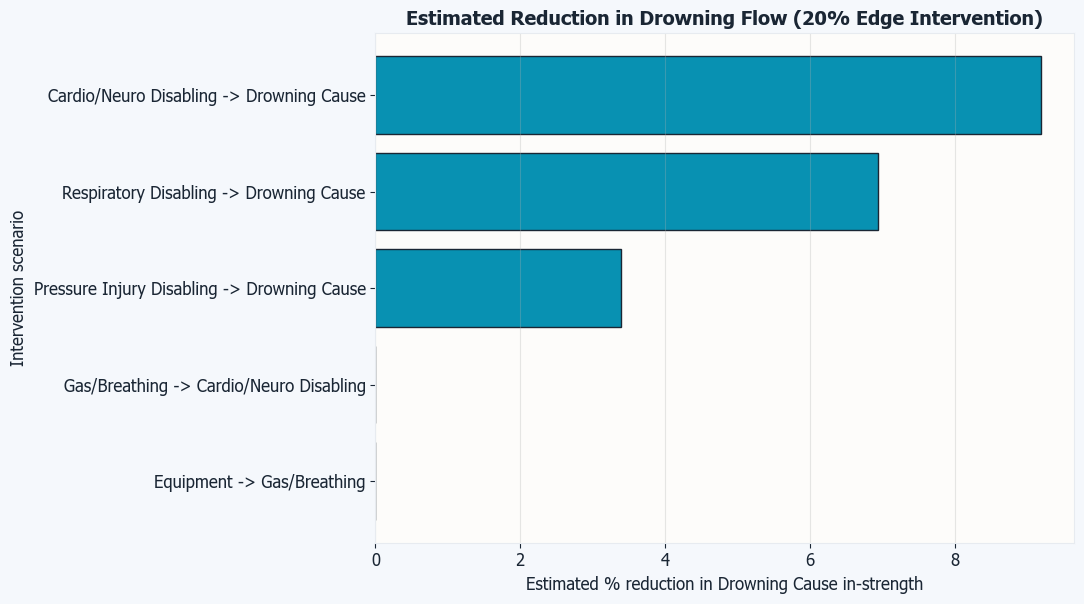


Top simulated intervention: Cardio/Neuro Disabling -> Drowning Cause at 30% -> 13.79% estimated reduction in Drowning Cause flow.
Exported figure: /Users/mirandagrein/Documents/final project/figures/network-analysis/08_intervention_impact_simulation_20pct.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "edge_df" not in globals():
    raise RuntimeError("`edge_df` is not available. Run the network-analysis cells above first.")

required_edges = [
    ("Equipment Trigger", "Gas / Breathing Mechanism", "Equipment -> Gas/Breathing"),
    ("Gas / Breathing Mechanism", "Cardiovascular / Neurological Disabling", "Gas/Breathing -> Cardio/Neuro Disabling"),
    ("Cardiovascular / Neurological Disabling", "Drowning Cause", "Cardio/Neuro Disabling -> Drowning Cause"),
    ("Drowning / Respiratory Disabling", "Drowning Cause", "Respiratory Disabling -> Drowning Cause"),
    ("Pressure Injury Disabling", "Drowning Cause", "Pressure Injury Disabling -> Drowning Cause"),
]

baseline_drowning_in = float(edge_df.loc[edge_df["target"] == "Drowning Cause", "weight"].sum())
if baseline_drowning_in <= 0:
    raise RuntimeError("Baseline flow into Drowning Cause is zero; check `edge_df` construction.")

reduction_levels = [0.10, 0.20, 0.30]
results = []

for source, target, label in required_edges:
    edge_exists = ((edge_df["source"] == source) & (edge_df["target"] == target)).any()
    if not edge_exists:
        print(f"Warning: edge not found and skipped: {source} -> {target}")
        continue

    for reduction in reduction_levels:
        simulated = edge_df.copy()
        mask = (simulated["source"] == source) & (simulated["target"] == target)
        simulated.loc[mask, "weight"] = simulated.loc[mask, "weight"] * (1 - reduction)

        new_drowning_in = float(simulated.loc[simulated["target"] == "Drowning Cause", "weight"].sum())
        absolute_reduction = baseline_drowning_in - new_drowning_in
        pct_reduction = (absolute_reduction / baseline_drowning_in) * 100

        results.append({
            "intervention": label,
            "edge": f"{source} -> {target}",
            "reduction_level": f"{int(reduction*100)}%",
            "baseline_drowning_in": baseline_drowning_in,
            "new_drowning_in": new_drowning_in,
            "absolute_reduction": absolute_reduction,
            "pct_reduction": pct_reduction,
        })

impact_df = pd.DataFrame(results)
if impact_df.empty:
    raise RuntimeError("No valid intervention edges found in `edge_df`.")

impact_df = impact_df.sort_values(["pct_reduction", "intervention"], ascending=[False, True]).reset_index(drop=True)

print("Intervention simulation results:")
display(impact_df)

summary_20 = (
    impact_df[impact_df["reduction_level"] == "20%"]
    .sort_values("pct_reduction", ascending=False)
    .reset_index(drop=True)
)

print("\n20% reduction scenario ranking:")
display(summary_20[["intervention", "pct_reduction", "absolute_reduction", "new_drowning_in"]])

pivot = impact_df.pivot_table(index="intervention", columns="reduction_level", values="pct_reduction", aggfunc="mean")
print("\nPercent reduction in Drowning Cause by intervention level:")
display(pivot)

fig, ax = plt.subplots(figsize=(11, 6.2))
plot_data = summary_20.sort_values("pct_reduction", ascending=True)
ax.barh(plot_data["intervention"], plot_data["pct_reduction"], color="#0891b2", edgecolor="#1a2634")
ax.set_title("Estimated Reduction in Drowning Flow (20% Edge Intervention)", fontsize=14, fontweight="bold")
ax.set_xlabel("Estimated % reduction in Drowning Cause in-strength")
ax.set_ylabel("Intervention scenario")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

export_dir = Path.cwd() / "figures" / "network-analysis"
export_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(export_dir / "08_intervention_impact_simulation_20pct.png", dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())

best_row = impact_df.iloc[0]
print(
    f"\nTop simulated intervention: {best_row['intervention']} at {best_row['reduction_level']} "
    f"-> {best_row['pct_reduction']:.2f}% estimated reduction in Drowning Cause flow."
)
print(f"Exported figure: {export_dir / '08_intervention_impact_simulation_20pct.png'}")